In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [2]:
train_df=pd.read_csv('/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv')
test_df=pd.read_csv('/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_validation.csv')

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [4]:
train_df=train_df.dropna()

In [5]:
train_df=train_df.drop_duplicates()

<Axes: xlabel='Positive', ylabel='count'>

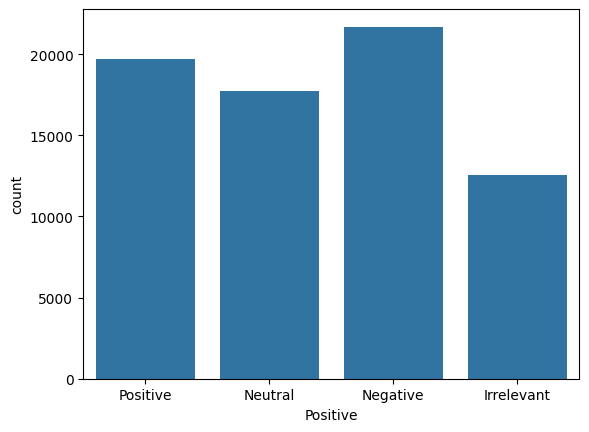

In [6]:
sns.countplot(x='Positive',data=train_df)

In [9]:
import random
random_sentences=random.sample(list(train_df['im getting on borderlands and i will murder you all ,']),5)
random_tags=[train_df[train_df['im getting on borderlands and i will murder you all ,']==sentence]['Positive'].iloc[0] for sentence in random_sentences]

In [10]:
for i,sentence in enumerate(random_sentences):
    print(f"The Sentence Tag: {random_tags[i]}")
    print(f"The Sentence {i+1}: {sentence}")
    print("\n")
    print("-"*50)

The Sentence Tag: Irrelevant
The Sentence 1: OMG! I never thought people could go down to this disgusting level! If you call them pigs, it would be an insult to pigs!


--------------------------------------------------
The Sentence Tag: Neutral
The Sentence 2: HEY. I don't know if anyone here rememebrs me but I'm restarting my stream. Hit top 200 in  


--------------------------------------------------
The Sentence Tag: Neutral
The Sentence 3: WOW DAY l My IAMBRYCETV puts on top all your socials!. Real World of Modern Warcraft. Amazon Twitch. tv / IAmBryceTV


--------------------------------------------------
The Sentence Tag: Irrelevant
The Sentence 4: Look at that damn unit, I'd love to smear its tight jacks


--------------------------------------------------
The Sentence Tag: Neutral
The Sentence 5: @ amazon I just accidentally pressed the cancellation option on my order that is due to ship today! Can you help me? I was not meant to press this option!


-------------------------

In [11]:
test_df['Irrelevant'].value_counts()

Irrelevant
Neutral       285
Positive      277
Negative      266
Irrelevant    171
Name: count, dtype: int64

In [12]:
train_df['Positive']=train_df['Positive'].map({'Negative':0,'Positive':1,'Neutral':2,'Irrelevant':3})
test_df['Irrelevant']=test_df['Irrelevant'].map({'Negative':0,'Positive':1,'Neutral':2,'Irrelevant':3})

In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71655 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   71655 non-null  int64 
 1   Borderlands                                            71655 non-null  object
 2   Positive                                               71655 non-null  int64 
 3   im getting on borderlands and i will murder you all ,  71655 non-null  object
dtypes: int64(2), object(2)
memory usage: 2.7+ MB


In [14]:
train_sentences,val_sentences,train_labels,val_labels=train_test_split(
    train_df['im getting on borderlands and i will murder you all ,'].to_numpy(),
    train_df['Positive'].to_numpy(),
    test_size=0.2,
    random_state=42
)

In [15]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

In [21]:
text_vectorizer = TextVectorization(
    max_tokens=10000,
    output_sequence_length=100,
    standardize='lower_and_strip_punctuation',
    output_mode='int'
)
text_vectorizer.adapt(train_sentences)

In [24]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    text_vectorizer,
    tf.keras.layers.Embedding(input_dim=10000, output_dim=128),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [25]:
history = model.fit(
    train_sentences, 
    train_labels, 
    epochs=10, 
    batch_size=64,
    validation_data=(val_sentences, val_labels),
    callbacks=[early_stopping]
)

Epoch 1/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.6205 - loss: 0.9233 - val_accuracy: 0.7346 - val_loss: 0.7058
Epoch 2/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7991 - loss: 0.5379 - val_accuracy: 0.7933 - val_loss: 0.5550
Epoch 3/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8554 - loss: 0.3891 - val_accuracy: 0.8110 - val_loss: 0.5173
Epoch 4/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8847 - loss: 0.3064 - val_accuracy: 0.8177 - val_loss: 0.5346
Epoch 5/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9037 - loss: 0.2556 - val_accuracy: 0.8323 - val_loss: 0.5203
Epoch 6/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9163 - loss: 0.2190 - val_accuracy: 0.8385 - val_loss: 0.5353


In [26]:
def plot_loss_accuracy(history):
    loss=history.history['loss']
    val_loss=history.history['val_loss']
    accuracy=history.history['accuracy']
    val_accuracy=history.history['val_accuracy']
    epochs=range(len(loss))
    plt.figure(figsize=(10,7))
    plt.subplot(1,2,1)
    plt.title("Training and Validation Loss")
    plt.plot(epochs,loss,label="Training Loss")
    plt.plot(epochs,val_loss,label="Validation Loss")
    plt.legend()
    plt.subplot(1,2,2)
    plt.title("Training and Validation Accuracy")
    plt.plot(epochs,loss,label="Training Accuracy")
    plt.plot(epochs,val_loss,label="Validation Accuracy")
    plt.legend()

    plt.show()

   

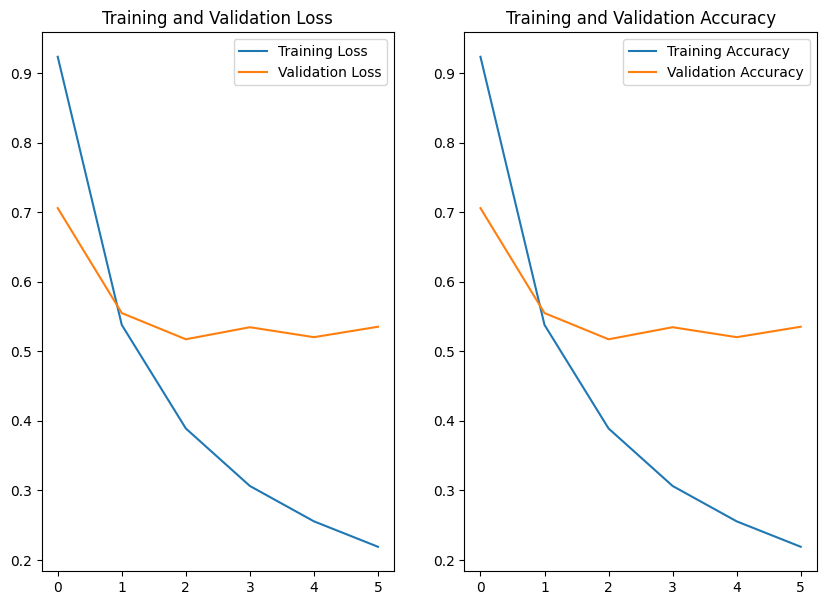

In [27]:
plot_loss_accuracy(history)

In [28]:
test_sentences=test_df['I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣'].to_numpy()
test_labels=test_df['Irrelevant'].to_numpy()

In [29]:
loss,accuracy=model.evaluate(test_sentences,test_labels)
print(f"Evaluation Loss :{loss}")
print(f"Evaluation Accuracy :{accuracy}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9169 - loss: 0.2462
Evaluation Loss :0.24624301493167877
Evaluation Accuracy :0.9169169068336487


In [35]:
predictions=model.predict(test_sentences)
predictions=tf.squeeze(tf.argmax(predictions,axis=1))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [39]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(test_labels,predictions))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       266
           1       0.94      0.91      0.93       277
           2       0.93      0.91      0.92       285
           3       0.92      0.92      0.92       171

    accuracy                           0.92       999
   macro avg       0.92      0.92      0.92       999
weighted avg       0.92      0.92      0.92       999



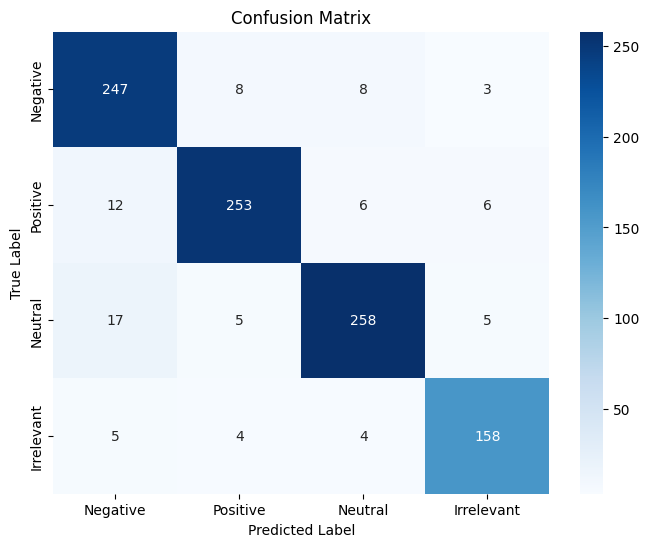

In [42]:
# Map the numerical labels back to their corresponding sentiment names
labels = ['Negative', 'Positive', 'Neutral', 'Irrelevant']

# Generate and plot confusion matrix
cm = confusion_matrix(test_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [63]:
# Testing a stronger, more direct negative sentence:
input_text = tf.constant(['I need to go buy some groceries like milk and eggs today.'])

pred_prob = model.predict(input_text)
pred_class = np.argmax(pred_prob, axis=1)[0]

print(labels[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Positive


In [51]:
# Array of test samples across different sentiment types
test_samples = [
    # 1. Tricky Negation / Sarcasm
    "I would never recommend this terrible service to anyone.",
    "Not bad at all, actually exceeded my expectations!",
    "Great, another bug that completely ruins the game...",
    
    # 2. Strong Positive
    "Absolutely amazing graphics and super smooth gameplay! Loved it.",
    "Best purchase I have made all year, worth every single penny.",
    
    # 3. Strong Negative
    "Complete waste of money, crashed five times in ten minutes.",
    "Horrible customer support and broken features everywhere.",
    
    # 4. Neutral / Informational
    "The new update was released today around 5 PM EST.",
    "I am currently downloading the patch file on my console."
]

# Run batch predictions
input_tensor = tf.constant(test_samples)
preds = model.predict(input_tensor)
pred_classes = np.argmax(preds, axis=1)

# Display results
for sample, pred_idx in zip(test_samples, pred_classes):
    print(f"[{labels[pred_idx]}] -> {sample}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
[Negative] -> I would never recommend this terrible service to anyone.
[Negative] -> Not bad at all, actually exceeded my expectations!
[Negative] -> Great, another bug that completely ruins the game...
[Positive] -> Absolutely amazing graphics and super smooth gameplay! Loved it.
[Positive] -> Best purchase I have made all year, worth every single penny.
[Negative] -> Complete waste of money, crashed five times in ten minutes.
[Negative] -> Horrible customer support and broken features everywhere.
[Positive] -> The new update was released today around 5 PM EST.
[Positive] -> I am currently downloading the patch file on my console.
